# The Real-Input Mirror
In Digital Signal Processing, when we feed **Real Numbers** (like a sensor reading) into an FFT, the math produces a mirrored result. 

Think of it like a reflection in a lake: the top half (Positive Frequencies) is the actual signal, and the bottom half (Negative Frequencies) is its mathematical shadow. 

Let's introduce our two friends:
* **Goliath:** A loud 30 Hz signal (0 dB).
* **David:** A quiet 200 Hz signal (-48 dB).

We'll start with "Perfect" integer frequencies to see the raw output of the hardware.

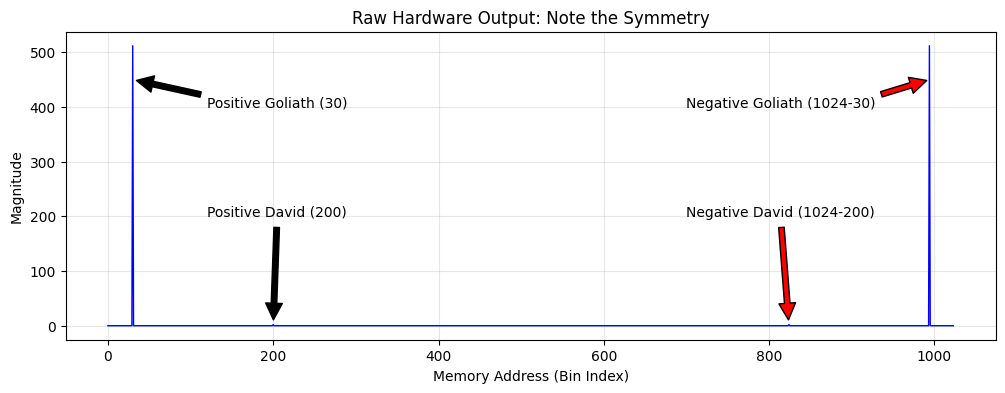

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim

N = 1024
t = np.arange(N)

# Perfect integer frequencies (30 and 200 cycles per buffer)
goliath = 1.0 * np.sin(2 * np.pi * 30 * t / N)
david = 10**(-48/20) * np.sin(2 * np.pi * 200 * t / N)

# The Raw Input
input_sig = goliath + david

# Run Hardware FFT
fft_raw, exp, _ = run_sim(input_sig, invert=False)
mag_raw = np.abs(fft_raw*(2**exp))

plt.figure(figsize=(12, 4))
plt.plot(mag_raw, 'b', linewidth=1)
plt.title("Raw Hardware Output: Note the Symmetry")
plt.xlabel("Memory Address (Bin Index)")
plt.ylabel("Magnitude")
plt.annotate('Positive Goliath (30)', xy=(30, 450), xytext=(120, 400), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Negative Goliath (1024-30)', xy=(994, 450), xytext=(700, 400), arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('Positive David (200)', xy=(200, 1), xytext=(120, 200), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Negative David (1024-200)', xy=(824, 1), xytext=(700, 200), arrowprops=dict(facecolor='red', shrink=0.05))
plt.grid(True, alpha=0.3)
plt.show()

## Centering the Spectrum
While the hardware stores data from `0` to `N-1`, humans usually prefer to see **0 Hz** in the center. 

We perform an `fftshift`, which swaps the halves of the array. This places the "Positive" frequencies on the right and the "Negative" frequencies on the left.

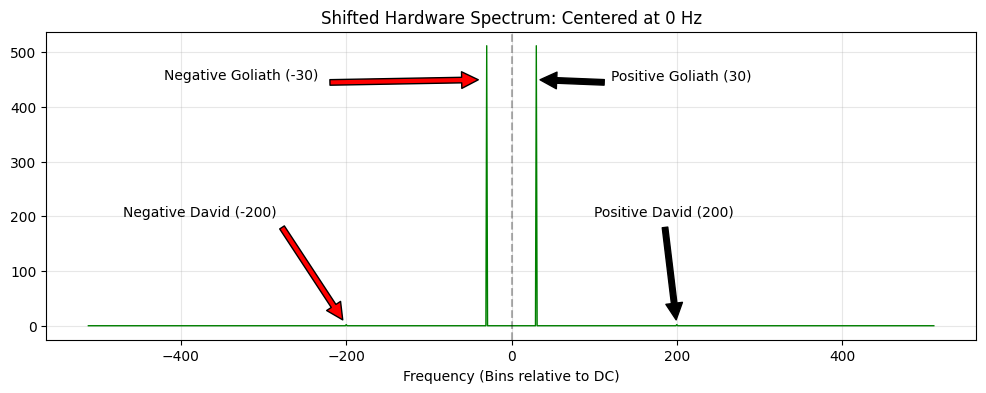

In [76]:
# Swap halves to put 0 Hz in the center
shifted_mag = np.fft.fftshift(mag_raw)
freq_axis = np.arange(-N//2, N//2)

plt.figure(figsize=(12, 4))
plt.plot(freq_axis, shifted_mag, 'g', linewidth=1)
plt.title("Shifted Hardware Spectrum: Centered at 0 Hz")
plt.xlabel("Frequency (Bins relative to DC)")
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.annotate('Positive Goliath (30)', xy=(30, 450), xytext=(120, 450), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Negative Goliath (-30)', xy=(-30, 450), xytext=(-420, 450), arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('Positive David (200)', xy=(200, 1), xytext=(100, 200), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Negative David (-200)', xy=(-200, 1), xytext=(-470, 200), arrowprops=dict(facecolor='red', shrink=0.05))
plt.grid(True, alpha=0.3)
plt.show()

# The Circulatory Property
The FFT assumes your 1024 samples repeat forever in a circle. If the end of your signal doesn't perfectly meet the beginning, you get a "Jump" (Discontinuity).

Let's change our frequencies to **30.5** and **200.5**. Now, the waves won't fit perfectly in the box. Let's look at the "seam" where the buffer wraps around.

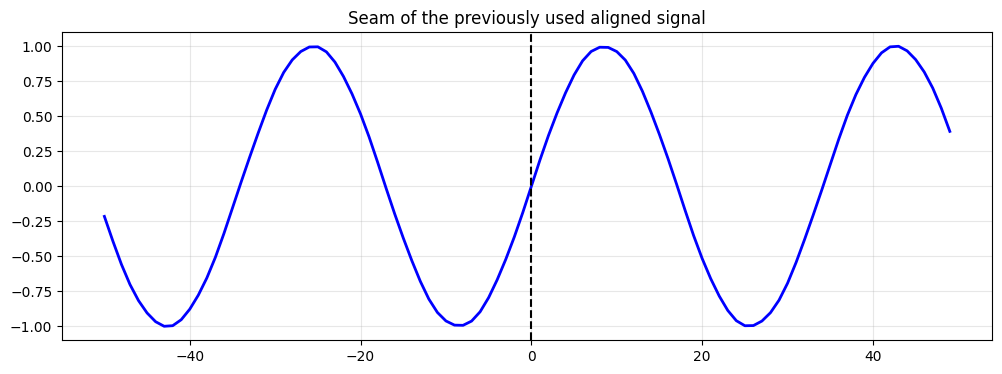

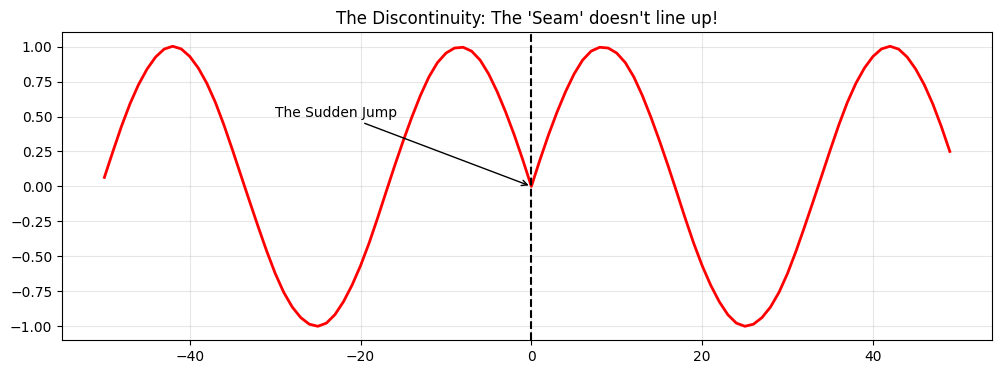

In [74]:
# Input signal "Seam"
seam = np.concatenate((input_sig[-50:], input_sig[:50]))

plt.figure(figsize=(12, 4))
plt.plot(np.arange(-50, 50), seam, 'b', linewidth=2)
plt.axvline(0, color='black', linestyle='--')
plt.title("Seam of the previously used aligned signal")
plt.grid(True, alpha=0.3)
plt.show()

# Non-integer frequencies create a "cliff" at the wrap-around
g_leak = 1.0 * np.sin(2 * np.pi * 30.5 * t / N)
d_leak = 10**(-50/20) * np.sin(2 * np.pi * 200.5 * t / N)
leaky_signal = g_leak + d_leak

# Visualize the wrap-around point (Last 50 samples + First 50 samples)
seam = np.concatenate((leaky_signal[-50:], leaky_signal[:50]))

plt.figure(figsize=(12, 4))
plt.plot(np.arange(-50, 50), seam, 'r', linewidth=2)
plt.axvline(0, color='black', linestyle='--')
plt.title("The Discontinuity: The 'Seam' doesn't line up!")
plt.annotate('The Sudden Jump', xy=(0, seam[50]), xytext=(-30, 0.5), arrowprops=dict(arrowstyle='->'))
plt.grid(True, alpha=0.3)
plt.show()

## Spectral Leakage: David is Drowning
Without a window, Goliath's energy "leaks" everywhere. Because David is so small, he doesn't look like a clean spike yet. 

**Observation Challenge:** Look closely at Bin 200. You won't see a clean peak. Instead, you'll see a **dip followed by a peak**. 
Why? Because David's signal and Goliath's leakage are both complex vectors. At this specific frequency, they are partially out of phase—they subtract from each other (creating a dip) before they add together (creating the peak). David is literally fighting against Goliath's "shadow" for visibility.

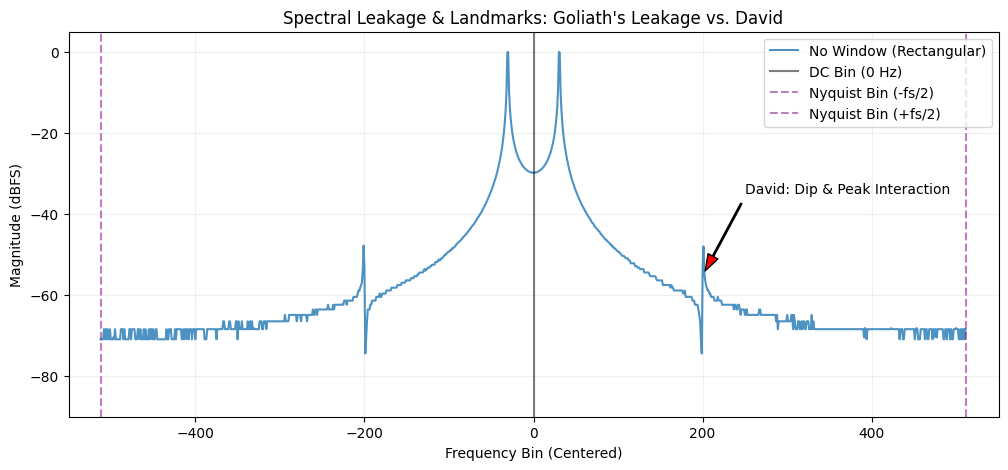

In [75]:
# Run the leaky signal through hardware WITHOUT a window
fft_leaky, _, _ = run_sim(leaky_signal, invert=False)

# Shift the results for the plot
fft_leaky_shift = np.fft.fftshift(fft_leaky)
mag_leaky_shift = 20 * np.log10(np.abs(fft_leaky_shift) / np.max(np.abs(fft_leaky_shift)) + 1e-12)
freq_axis = np.arange(-N//2, N//2)

plt.figure(figsize=(12, 5))
plt.plot(freq_axis, mag_leaky_shift, label="No Window (Rectangular)", alpha=0.8)

# --- Add Landmarks ---
plt.axvline(0, color='black', linestyle='-', alpha=0.5, label="DC Bin (0 Hz)")
plt.axvline(-N//2, color='purple', linestyle='--', alpha=0.5, label="Nyquist Bin (-fs/2)")
plt.axvline(N//2-1, color='purple', linestyle='--', alpha=0.5, label="Nyquist Bin (+fs/2)")

# --- Annotate David's Struggle ---
plt.annotate('David: Dip & Peak Interaction', xy=(200.5, -55), xytext=(250, -35),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=8))

plt.ylim([-90, 5])
plt.xlim([-550, 550]) # Zoom in slightly to see the peaks and landmarks
plt.title("Spectral Leakage & Landmarks: Goliath's Leakage vs. David")
plt.xlabel("Frequency Bin (Centered)")
plt.ylabel("Magnitude (dBFS)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

## The Solution: Windowing
By multiplying by a **Hann Window**, we force the signal to zero at the edges, removing the "cliff." 

Notice how the "Dip and Peak" struggle disappears. Once Goliath's leakage is suppressed, David's vector no longer has anything to subtract from. He emerges as a clean, predictable peak, standing safely above the noise floor.

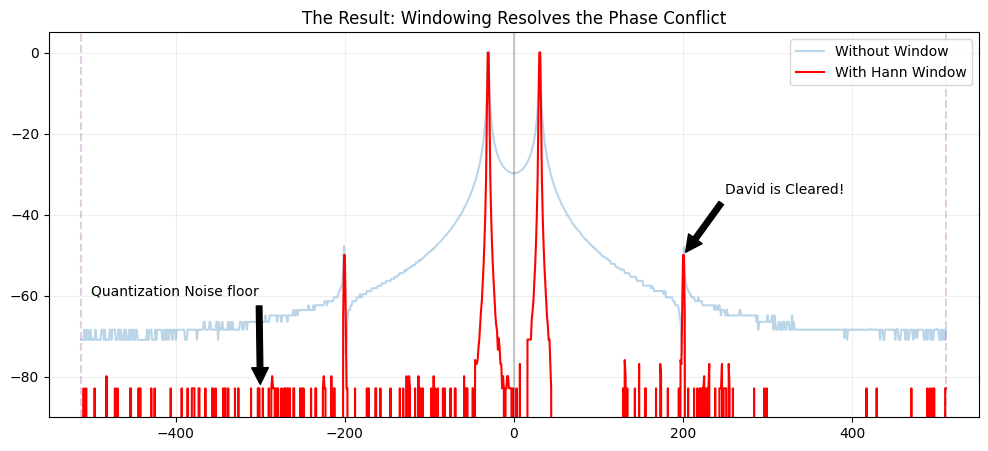

In [70]:
# Apply Hann Window and Shift
windowed_signal = leaky_signal * np.hanning(N)
fft_win, _, _ = run_sim(windowed_signal, invert=False)
mag_win_shift = 20 * np.log10(np.abs(np.fft.fftshift(fft_win)) / np.max(np.abs(fft_win)) + 1e-12)

plt.figure(figsize=(12, 5))
plt.plot(freq_axis, mag_leaky_shift, label="Without Window", alpha=0.3)
plt.plot(freq_axis, mag_win_shift, 'r', label="With Hann Window", linewidth=1.5)

# Landmarks
plt.axvline(0, color='black', linestyle='-', alpha=0.2)
plt.axvline(-N//2, color='purple', linestyle='--', alpha=0.2)
plt.axvline(N//2-1, color='purple', linestyle='--', alpha=0.2)

plt.ylim([-90, 5])
plt.xlim([-550, 550])
plt.title("The Result: Windowing Resolves the Phase Conflict")
plt.annotate('David is Cleared!', xy=(200.5, -50), xytext=(250, -35),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Quantization Noise floor', xy=(-300, -83), xytext=(-500, -60),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### Summary
1. **Mirroring:** Real inputs create symmetric spectra. Hardware gives you both halves; we usually shift them for clarity.
2. **The Circular Assumption:** The FFT assumes a perfect loop. Non-integer frequencies break this loop.
3. **Leakage:** Breaking the loop causes a "jump" that masks or distorsts quiet signals.
4. **Windowing:** By smoothing the edges, we trade a little frequency resolution for a massive increase in **Dynamic Range**.

Now that we understand how to clean our signals, let's move to the next notebook to see how the FFT helps us find signals buried in absolute chaos.